In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import sys
import pickle

from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

import functools

# Data Exploration
Raw recieved data from `zasilka-TP4VGT9M89DDMFIM` are split and concatenated in such a way so we now I a .csv file per one water meter (per id).

Script `split_and_concat_dfs.py` is used for this purpose.

Finished data is in `data` folder.

In this notebook data will be examined.

## Example Water Meter 

In [2]:
example_df = pd.read_csv("./data/2328.csv")
example_df.tail()

,id,timestamp,hodnota
3102,2328,2020-08-05 10:23:19,522.047
3103,2328,2020-08-05 11:23:20,522.053
3104,2328,2020-08-05 11:53:18,522.053
3105,2328,2020-08-05 12:23:18,522.054
3106,2328,2020-08-05 14:53:19,522.058


In [3]:
example_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         3107 non-null   int64  
 1   timestamp  3107 non-null   object 
 2   hodnota    3107 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 72.9+ KB


## Create Diff column
Create column with values equal to `df[hodnota][t]` - `df[hodnota][t-1]`.

All of this is done in `create_diff.py` script.

Processed data is in `data_final` folder.

## Number of Water Meters

In [43]:
all_dfs_paths = [f"./data/{filename}" for filename in os.listdir('data')] 
print(f"Total number of Water Meters: {len(all_dfs_paths)}")

Total number of Water Meters: 27603


### Check Sorting
Check if all values in `timestamp` and `hodnota` column are sorted.

We sort all df based on `timestamp` but many values stay unsorted based on `hodnota`. Let examine them

In [4]:
for filename in os.listdir('./data'):
    if filename.endswith('.csv'):
        filepath = os.path.join('./data', filename)
        df = pd.read_csv(filepath)
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
        if not df['timestamp'].is_monotonic_increasing:
            print(f"File not sorted: {filename}")
            break

File not sorted: 100038.csv


In [5]:
# Load the CSV file
filename = "./data/4271.csv"
df = pd.read_csv(filename)

# Convert the timestamp column to datetime
timestamp_col = 'timestamp'
df[timestamp_col] = pd.to_datetime(df[timestamp_col])

# Find where timestamp is not sorted (previous timestamp > current timestamp)
unsorted_indices = df.index[df[timestamp_col].diff() < pd.Timedelta(0)].tolist()

# Show rows where unsorted breaks occur including the previous row for context
for idx in unsorted_indices:
    print(df.iloc[idx-1:idx+1])
    
values_no_na = df["hodnota"].dropna()
print(values_no_na.is_monotonic_increasing)

unsorted_indices = df.index[df["hodnota"].diff() < 0].tolist()

for idx in unsorted_indices:
    print(df.iloc[idx-1:idx+1])

False
     id           timestamp  hodnota
1  4271 2020-03-04 17:31:53    4.032
2  4271 2020-03-04 19:32:53    4.031


In [44]:
unsorted_values_dfs_dir = './data_sorted_timestamp_decrease_value/'
unsorted_values_dfs_paths = os.listdir('./data_sorted_timestamp_decrease_value/')

print(f"Number of files where values sorting doesn't match after sorting timestamp: {len(unsorted_values_dfs_paths)} out of {len(all_dfs_paths)}")

Number of files where values sorting doesn't match after sorting timestamp: 7290 out of 27603


In [7]:
random_unsorted_df = pd.read_csv(f"{unsorted_values_dfs_dir}/{unsorted_values_dfs_paths[200]}")
unsorted_indices = random_unsorted_df.index[random_unsorted_df["hodnota"].diff() < -0.000].tolist()

for idx in unsorted_indices:
    print(random_unsorted_df.iloc[idx-1:idx+1])
#for df_path in unsorted_values_dfs_paths:

       id            timestamp  hodnota
2  103248  2021-08-23 13:20:14    0.124
3  103248  2021-08-24 00:00:01    0.120
          id            timestamp  hodnota
5477  103248  2022-06-29 22:48:13    4.858
5478  103248  2022-06-29 23:48:26    4.857
          id            timestamp  hodnota
5479  103248  2022-06-30 00:48:40    4.857
5480  103248  2022-06-30 01:48:52    4.856
          id            timestamp  hodnota
5481  103248  2022-06-30 02:49:05    4.856
5482  103248  2022-06-30 03:49:18    4.855
          id            timestamp  hodnota
5483  103248  2022-06-30 04:49:31    4.855
5484  103248  2022-06-30 05:49:47    4.854
          id            timestamp  hodnota
5485  103248  2022-06-30 06:49:58    4.854
5486  103248  2022-06-30 07:50:10    4.853
          id            timestamp  hodnota
9946  103248  2023-01-15 19:06:17    6.055
9947  103248  2023-01-15 20:06:30    6.054
          id            timestamp  hodnota
9948  103248  2023-01-15 21:06:44    6.054
9949  103248  2023-0

In [32]:
def get_pickle_data(pickle_path, function, params):
    if os.path.exists(pickle_path):
        with open(pickle_path, 'rb') as file:
            data = pickle.load(file)
    else:
        data = function(*params)
        with open(pickle_path, 'wb') as f:
            pickle.dump(data, f)
    return data

In [ ]:
def diff_bigger_than(df_filename: str, difference = -0.002) -> int:
    df = pd.read_csv(f"{unsorted_values_dfs_dir}/{df_filename}")
    
    unsorted_indices = df.index[df["hodnota"].diff() < difference].tolist()
    return df_filename, unsorted_indices

def files_bigger_than(file_paths: list, difference) -> dict:
    return dict(map(lambda filename: diff_bigger_than(filename, difference=difference), file_paths))

In [37]:
unsorted_indeces_all_files_diff_002 = get_pickle_data('./pickles/unsorted_idxs_all_files_diff_002', files_bigger_than, [unsorted_values_dfs_paths, -0.002])
unsorted_indeces_all_files_diff_000 = get_pickle_data('./pickles/unsorted_idxs_all_files_diff_000', files_bigger_than, [unsorted_values_dfs_paths, 0])

In [47]:
empty_indices_filenames_002 = [filename for filename, indices in unsorted_indeces_all_files_diff_002.items() if len(indices) == 0]
empty_indices_filenames_000 = [filename for filename, indices in unsorted_indeces_all_files_diff_000.items() if len(indices) == 0]
print(f"Number of files that have unsorted indices with difference bigger than 0.002: {len(unsorted_indeces_all_files_diff_000) - len(empty_indices_filenames_002)}")

Number of files that have unsorted indices with difference bigger than 0.002: 5994


In [39]:
num_unsort_idxs_002 = sum(len(unsorted_indices_value) for unsorted_indices_value in unsorted_indeces_all_files_diff_002.values())
num_unsort_idxs_000 = sum(len(unsorted_indices_value) for unsorted_indices_value in unsorted_indeces_all_files_diff_000.values())

print(f"Total number of unsorted indexes in all files is {num_unsort_idxs_000}")
print(f"If we allow 0.001 diff tolerance then it is {num_unsort_idxs_002}")

Total number of unsorted indexes in all files is 297075
If we allow 0.001 diff tolerance then it is 161108


In [40]:
def count_unsorted_after_date(df_filename: str, unsorted_indices: list, date_str="2024-01-01") -> int:
    df = pd.read_csv(f"{unsorted_values_dfs_dir}/{df_filename}")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    cutoff_date = pd.to_datetime(date_str)
    
    filtered_indices = [idx for idx in unsorted_indices if df.loc[idx, "timestamp"] > cutoff_date]
    return len(filtered_indices)

def sum_after_date(unsorted_indices_dict, date_str="2024-01-01"):
    return sum(
        count_unsorted_after_date(filename, indices, date_str) 
        for filename, indices in unsorted_indices_dict.items()
    )

In [41]:
total_after_date_002 = get_pickle_data('./pickles/total_after_date_002.pkl', sum_after_date, [unsorted_indeces_all_files_diff_002]) 
total_after_date_000 = get_pickle_data('./pickles/total_after_date_000.pkl', sum_after_date, [unsorted_indeces_all_files_diff_000]) 

print(f"Total unsorted indices after 2024-01-01: {total_after_date_000}")
print(f"If we allow 0.001 tolerance: {total_after_date_002}")

Total unsorted indices after 2024-01-01: 164491
If we allow 0.001 tolerance: 80330


Since we havent managed to figure out how to deal with the unsorted `hodnota` values the `Diff` values are calculated regardless but when the value would be negative a NaN value is added.

### Add Diff

`Diff` column in added in `create_diff.py` file.

In [17]:
example_df = pd.read_csv('./data_sorted_timestamp/111227.csv')
example_df.head()

,id,timestamp,hodnota,Diff
0,111227,2022-04-21 05:03:01,0.200,0.000
1,111227,2022-04-25 16:46:32,38.142,37.942
2,111227,2022-04-25 17:46:49,38.568,0.426
3,111227,2022-04-25 19:47:24,39.679,1.111
4,111227,2022-04-25 22:48:17,42.142,2.463


## Add Metadata

New folder called `metadata` created where metadata (json files) are placed. Each file has the same name as a corresponding water meter ID.

Metadata are created in file `create_metadata.py`

In [18]:
import json

with open("metadata/111227.json", 'r') as f:
    example_metadata = json.load(f)
    
print(example_metadata)

{'num_records': 9288, 'start_time': '2022-04-21 05:03:01', 'end_time': '2025-10-07 23:17:49', 'value_min': 0.2, 'value_max': 10355.422, 'value_mean': 4633.054635874247, 'value_std': 3414.5943346175854, 'diff_min': 0.0, 'diff_max': 320.029, 'diff_mean': 1.1149033161068045, 'diff_std': 5.182698632616613, 'nan_value_count': 0, 'nan_diff_count': 0, 'common_periodicity_seconds': 3617.0, 'num_gaps_over_5min': 4224}


## Number of Records
Histogram of number of records

In [ ]:
def metadata_to_list(key_name, folder='./metadata') -> list:
    '''
    Returns a list with metadata values of a given key values in parameter
    '''
    res = []
    
    for json_file in os.listdir(folder):
        json_path = os.path.join(folder, json_file)
        try:
            with open(json_path, 'r') as f:
                metadata =  json.load(f)
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON file {json_path}: {e}", file=sys.stderr)
            raise
        
        res.append(metadata[key_name])
    
    return res

In [56]:
def plot_histogram_with_stats(values, title='Histogram', bins='auto', density=False, x_range=None):
    """
    Generate a histogram from a list of values and display a stats box.

    Parameters:
    - values: list or array of numeric data
    - title: title of the plot
    - bins: number of histogram bins
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    min_val = np.min(values)
    max_val = np.max(values)
    
    if not x_range:
        x_range = (min_val, max_val)
    
    # Plot histogram
    ax.hist(values, bins=bins, density=density, range=x_range, color='skyblue', edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

    # Calculate stats
    mean_val = np.mean(values)
    std_val = np.std(values)

    # Prepare stats text
    stats_lines = [
        f"Min: {min_val:.2f}",
        f"Max: {max_val:.2f}",
        f"Mean: {mean_val:.2f}",
        f"Std: {std_val:.2f}"
    ]
    stats_text = "\n".join(stats_lines)
    
    # Determine font size based on number of stats lines
    font_size = max(8, min(10, 10 - len(stats_lines) // 2))

    # Add stats box to the plot
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.show()


In [57]:
number_of_records = get_pickle_data('./pickles/number_of_records', metadata_to_list, ['num_records'])

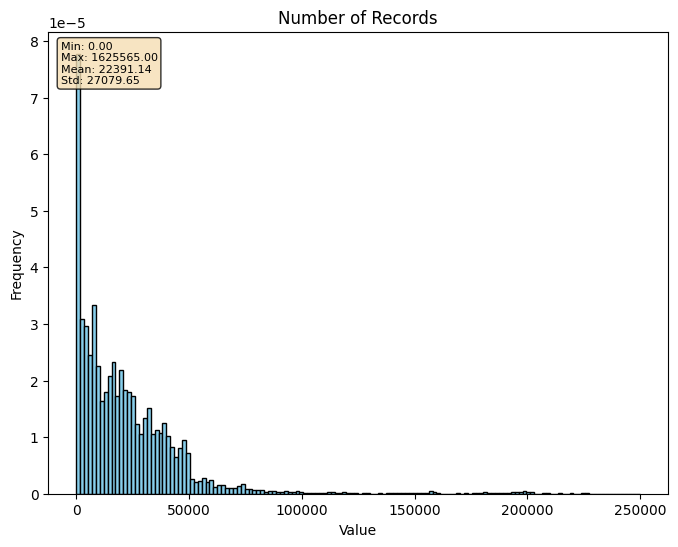

In [58]:
plot_histogram_with_stats(number_of_records, title='Number of Records', density=True, x_range=(0, 0.25e6))

## Duration
Examine duration of measurements on the meter

In [ ]:
start_dates = metadata_to_list('start_time')
end_dates = metadata_to_list('end_time')
start_dates = pd.to_datetime(start_dates, errors='coerce')
end_dates = pd.to_datetime(end_dates, errors='coerce')

durations = (end_dates - start_dates).to_list()
plot_histogram_with_stats(durations, "Duration of measurement")

KeyboardInterrupt: 

In [ ]:
def is_active(end_date) -> bool:
    '''
    Returns True if water meter contains data from September 2025, else False
    '''
    september_date = datetime.strptime("2025-09-01", "%Y-%m-%d")
    return end_date >= september_date

print(f"Number of meters that are active as of September 2025: {len([end_date for end_date in end_dates if is_active(end_date)])}")

In [ ]:
plot_histogram_with_stats(end_dates, "Histogram of End Dates")

## NaN values in Diff and hodnota

In [14]:
def is_active(df_path: str) -> bool:
    '''
    Returns True if water meter contains data from September 2025, else False
    '''
    df = pd.read_csv(df_path)
    last_date =  datetime.strptime(df['timestamp'].iloc[-1], "%Y-%m-%d %H:%M:%S")
    september_date = datetime.strptime("2025-09-01", "%Y-%m-%d")
    return last_date >= september_date

In [15]:
print(f"Number of all active water meters is: {all(map(is_active, all_dfs_paths))}")

Number of all active water meters is: False


In [16]:
first_export.head()

NameError: name 'first_export' is not defined

In [ ]:
first_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23646713 entries, 0 to 23646712
Data columns (total 3 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   timestamp  object 
 2   hodnota    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 541.2+ MB


In [ ]:
first_export['id'].nunique()

4681

In [ ]:
first_export.isna().values.sum()

2818

In [ ]:
first_export[first_export.isna().any(axis=1)]

,id,timestamp,hodnota
4848234,71934,2020-05-28 10:39:22,NaN
4848235,71934,2020-05-28 10:40:32,NaN
4848236,71934,2020-05-28 10:41:42,NaN
4848237,71934,2020-05-28 10:42:23,NaN
4848238,71934,2020-05-28 10:45:30,NaN
...,...,...,...
16208682,85696,2020-10-16 09:14:49,NaN
16208683,85696,2020-10-16 10:14:50,NaN
16208684,85696,2020-10-16 11:14:51,NaN
16208685,85696,2020-10-16 11:18:26,NaN


In [ ]:
first_export['id'].isna().values.sum()

0

In [ ]:
split_dfs = {group_id: group_df for group_id, group_df in first_export.groupby('id')}

In [ ]:
split_dfs[71934][split_dfs[71934].isna().any(axis=1)].head()

,id,timestamp,hodnota
4848234,71934,2020-05-28 10:39:22,NaN
4848235,71934,2020-05-28 10:40:32,NaN
4848236,71934,2020-05-28 10:41:42,NaN
4848237,71934,2020-05-28 10:42:23,NaN
4848238,71934,2020-05-28 10:45:30,NaN


In [ ]:
def split_and_save_df(df: pd.DataFrame):
    split_dfs = {group_id: group_df for group_id, group_df in df.groupby('id')}
    
    first_df = list(split_dfs.values())[0]
    year = first_df["timestamp"].iloc[0].split("-")[0]
    print(year)
    
    for df_id, df_values in split_dfs.items():
        df_values.to_csv(f"split_data/{df_id}-{year}.csv")
    
split_and_save_df(first_export)

2020
